# Finsight EDA — Preliminary Visualisation Examples
This notebook builds a **mock transaction dataset** (same structure as the real dataset: `client_id`, `bank_id`, `account_id`, `txn_id`, `txn_date`, `description`, `amount`, `category`) and produces the preliminary graphs listed in Section 5.2 (Data Visualisation) and 5.3 (Correlation Analysis) of the Finsight EDA plan.

Nothing here is real data — it's randomly generated so you can preview what each chart will look like once the real dataset is loaded.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)  # keeps the mock data reproducible
plt.rcParams["figure.figsize"] = (8, 5)


In [2]:
# ---- Build a mock dataset that mirrors the real Finsight dataset's columns ----

n_rows = 5000
n_clients = 150
n_banks = 5
categories = ["Groceries", "Transport", "Utilities", "Entertainment", "Health", "Education", "Other Services"]

# Give categories different typical spend ranges and frequencies, so the mock charts look realistic
category_weights   = [0.30, 0.20, 0.15, 0.15, 0.08, 0.05, 0.07]     # how common each category is
category_amount_mu = [450,  180,  900,  250,  600,  1200, 300]      # rough average amount (ZAR) per category
category_amount_sd = [200,  80,   300,  150,  400,  500,  200]

client_id  = np.random.randint(1, n_clients + 1, n_rows)
bank_id    = np.random.randint(1, n_banks + 1, n_rows)
account_id = client_id * 10 + np.random.randint(0, 2, n_rows)   # 1-2 accounts per client
txn_id     = np.arange(1, n_rows + 1)

category = np.random.choice(categories, size=n_rows, p=category_weights)

# amount depends on category, and can't be negative
amount = np.array([
    max(5, np.random.normal(category_amount_mu[categories.index(c)], category_amount_sd[categories.index(c)]))
    for c in category
]).round(2)

# spread transaction dates over one year, with slightly more activity at month-end (rent/bills)
base_dates = pd.to_datetime("2025-01-01") + pd.to_timedelta(np.random.randint(0, 365, n_rows), unit="D")
txn_date = base_dates

merchants = {
    "Groceries": ["Checkers Hyper", "Woolworths", "Pick n Pay", "Shoprite"],
    "Transport": ["Uber Trip", "Bolt Ride", "Gautrain", "Shell Fuel"],
    "Utilities": ["City Power Prepaid", "Rand Water", "DSTV"],
    "Entertainment": ["Showmax Subscription", "Ster-Kinekor", "Spotify"],
    "Health": ["Clicks Pharmacy", "Dis-Chem", "Netcare"],
    "Education": ["Eduvos Fees", "Takealot Books"],
    "Other Services": ["Takealot Order", "Post Office", "Bank Fee"],
}
description = [np.random.choice(merchants[c]) for c in category]

df = pd.DataFrame({
    "client_id": client_id,
    "bank_id": bank_id,
    "account_id": account_id,
    "txn_id": txn_id,
    "txn_date": txn_date,
    "description": description,
    "amount": amount,
    "category": category,
})

df.head()


,client_id,bank_id,account_id,txn_id,txn_date,description,amount,category
0,103,1,1030,1,2025-08-12,Bolt Ride,240.56,Transport
1,93,1,931,2,2025-04-11,Netcare,875.98,Health
2,15,4,150,3,2025-07-23,Showmax Subscription,219.97,Entertainment
3,107,5,1070,4,2025-01-08,Rand Water,1105.02,Utilities
4,72,4,720,5,2025-06-21,Bolt Ride,5.00,Transport


## Histogram — Transaction Amounts

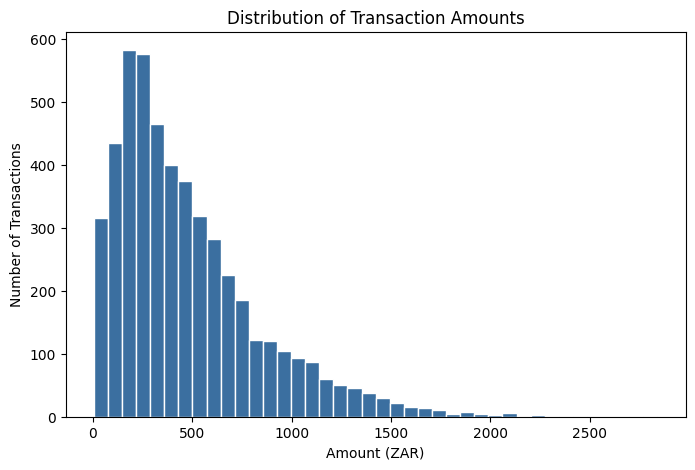

In [3]:
plt.hist(df["amount"], bins=40, color="#3b6fa0", edgecolor="white")
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Amount (ZAR)")
plt.ylabel("Number of Transactions")
plt.show()


## Bar Chart — Total Monetary Value per Category

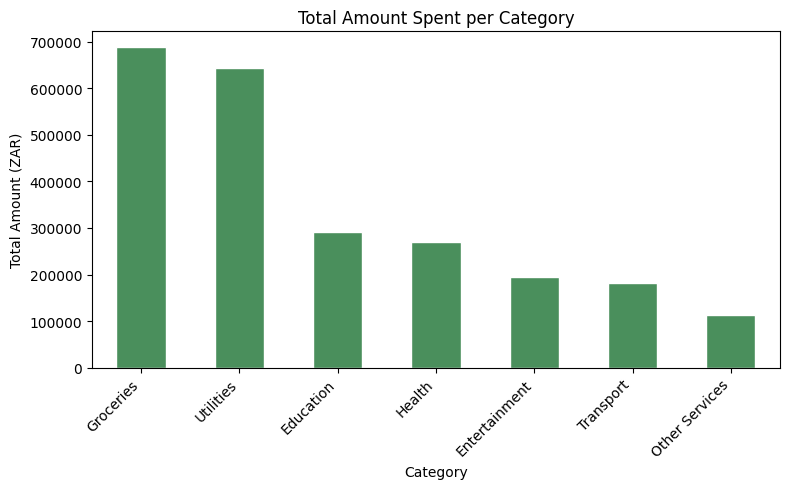

In [4]:
category_totals = df.groupby("category")["amount"].sum().sort_values(ascending=False)

category_totals.plot(kind="bar", color="#4a8f5c", edgecolor="white")
plt.title("Total Amount Spent per Category")
plt.xlabel("Category")
plt.ylabel("Total Amount (ZAR)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Pie Chart — Proportion of Transactions per Category

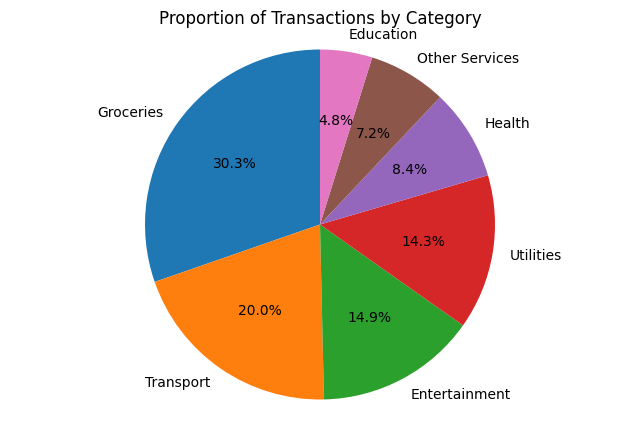

In [5]:
category_counts = df["category"].value_counts()

plt.pie(category_counts, labels=category_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Proportion of Transactions by Category")
plt.axis("equal")
plt.show()


## Line Chart — Transactions Over Time (by Date)

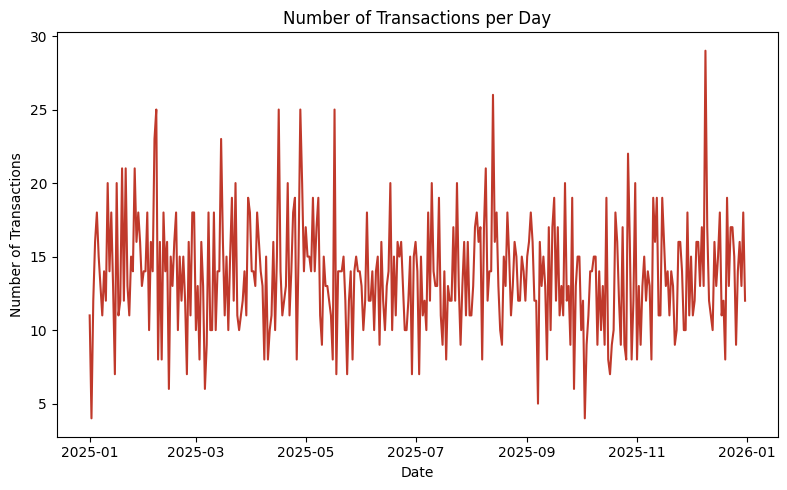

In [6]:
daily = df.groupby(df["txn_date"].dt.date).size()

daily.plot(kind="line", color="#c0392b")
plt.title("Number of Transactions per Day")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()


## Bar Chart — Transactions per Client (Top 15, due to volume)

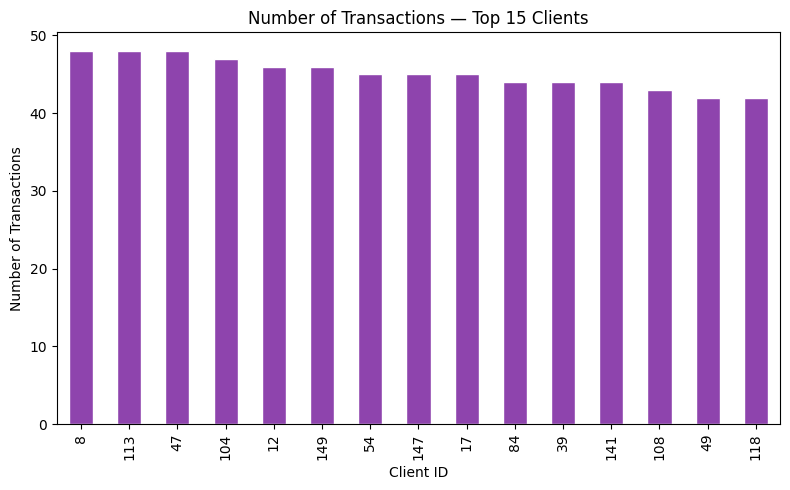

In [7]:
top_clients = df["client_id"].value_counts().head(15)

top_clients.plot(kind="bar", color="#8e44ad", edgecolor="white")
plt.title("Number of Transactions — Top 15 Clients")
plt.xlabel("Client ID")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()


## Bar Chart — Transactions and Value per Bank

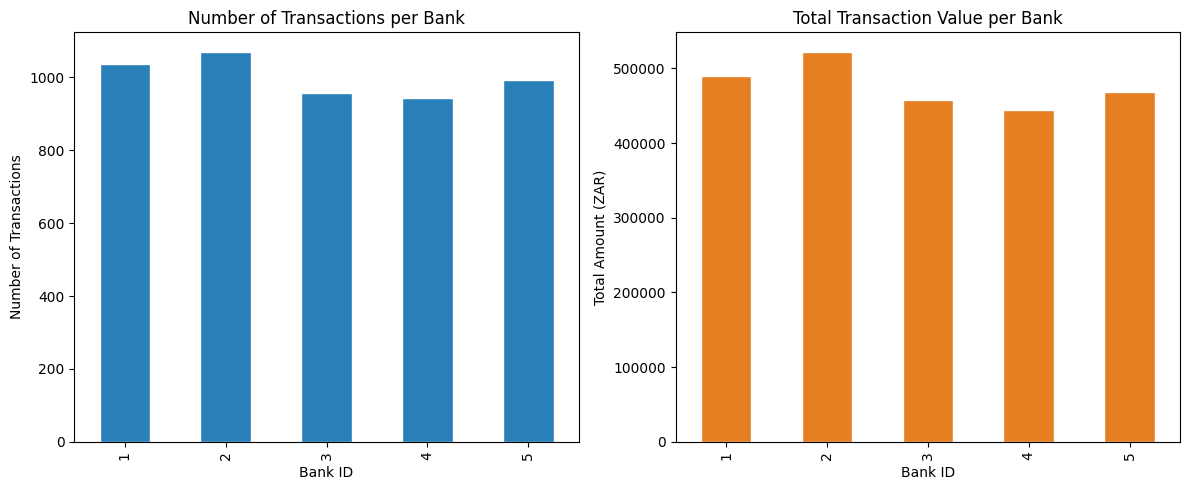

In [8]:
bank_summary = df.groupby("bank_id").agg(
    num_transactions=("txn_id", "count"),
    total_value=("amount", "sum")
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bank_summary["num_transactions"].plot(kind="bar", ax=axes[0], color="#2980b9", edgecolor="white")
axes[0].set_title("Number of Transactions per Bank")
axes[0].set_xlabel("Bank ID")
axes[0].set_ylabel("Number of Transactions")

bank_summary["total_value"].plot(kind="bar", ax=axes[1], color="#e67e22", edgecolor="white")
axes[1].set_title("Total Transaction Value per Bank")
axes[1].set_xlabel("Bank ID")
axes[1].set_ylabel("Total Amount (ZAR)")

plt.tight_layout()
plt.show()


## 5.3 Correlation Analysis
Builds an **account-level** summary table (as described in the EDA plan) and shows the correlation matrix between numeric account-level features.

In [9]:
account_level = df.groupby("account_id").agg(
    num_transactions=("txn_id", "count"),
    total_value=("amount", "sum"),
    avg_amount=("amount", "mean"),
    median_amount=("amount", "median"),
    std_amount=("amount", "std"),
    num_categories=("category", "nunique"),
    first_txn=("txn_date", "min"),
    last_txn=("txn_date", "max"),
)
account_level["days_active"] = (account_level["last_txn"] - account_level["first_txn"]).dt.days
account_level = account_level.drop(columns=["first_txn", "last_txn"]).fillna(0)

correlation_matrix = account_level.corr(numeric_only=True)
correlation_matrix


,num_transactions,total_value,avg_amount,median_amount,std_amount,num_categories,days_active
num_transactions,1.000000,0.780333,-0.013038,-0.033250,0.073468,0.503667,0.301840
total_value,0.780333,1.000000,0.591612,0.442431,0.465301,0.520383,0.251833
avg_amount,-0.013038,0.591612,1.000000,0.798143,0.665711,0.215442,0.041391
median_amount,-0.033250,0.442431,0.798143,1.000000,0.244285,0.112785,0.047902
std_amount,0.073468,0.465301,0.665711,0.244285,1.000000,0.268540,0.071338
num_categories,0.503667,0.520383,0.215442,0.112785,0.268540,1.000000,0.201544
days_active,0.301840,0.251833,0.041391,0.047902,0.071338,0.201544,1.000000


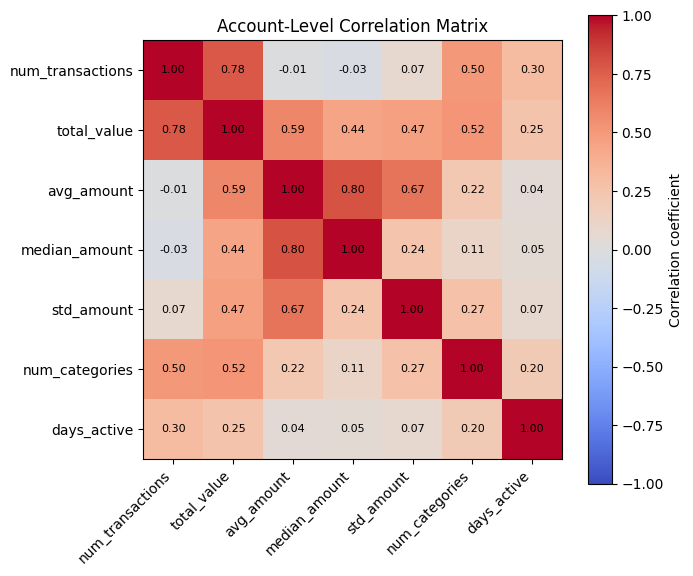

In [10]:
# Heatmap of the correlation matrix (matplotlib only, no seaborn needed)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(correlation_matrix.columns)

# annotate each cell with its correlation value
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        ax.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=8)

plt.colorbar(im, label="Correlation coefficient")
plt.title("Account-Level Correlation Matrix")
plt.tight_layout()
plt.show()


### Amount vs. Transaction Date (does spend change over the month?)
Quick check for the "obligation payments at month-end" idea mentioned in the EDA plan.

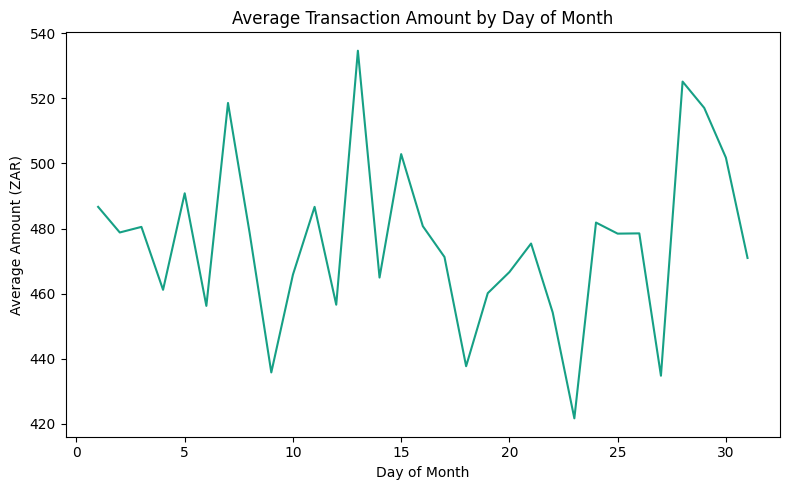

In [11]:
df["day_of_month"] = df["txn_date"].dt.day
avg_by_day = df.groupby("day_of_month")["amount"].mean()

avg_by_day.plot(kind="line", color="#16a085")
plt.title("Average Transaction Amount by Day of Month")
plt.xlabel("Day of Month")
plt.ylabel("Average Amount (ZAR)")
plt.tight_layout()
plt.show()
